# Task 1.1 — Sentiment Analysis with a Feedforward ANN

We classify Amazon product reviews as **positive (1)** or **negative (0)** using a
TF-IDF bag-of-words representation fed into a simple feedforward neural network.

**Pipeline overview**
```
Raw text  →  Preprocessing  →  TF-IDF vectors  →  ANN  →  {0, 1}
```

## Setup & Imports

In [1]:
import warnings
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from data_loading_code import preprocess_pandas
from utils import device_check, fit, evaluate
from plotting_tools import plot_confusion_matrix

# Suppress NumPy 2.4 VisibleDeprecationWarning triggered inside torchvision
warnings.filterwarnings("ignore", category=np.exceptions.VisibleDeprecationWarning)

device = device_check()

PyTorch: 2.11.0+cu130 | Python: 3.11.15 | OS: Linux 5.15.0-168-generic
CUDA available: True
GPUs: 1 x NVIDIA GeForce RTX 2080 Ti (11.3 GB)
CUDA: 13.0 | cuDNN: 91900
Using cuda / NVIDIA GeForce RTX 2080 Ti


In [2]:
LOG_WANDB   = True  # Set False to disable wandb logging
NUM_WORKERS = 8
PIN_MEMORY  = True
SEED = 1

# Make results reproducible
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## ANN Design

A feedforward network with **BatchNorm** and **Dropout** for regularization, with adjustable hidden layer count/size.

In [3]:
class SentimentANN(nn.Module):
    def __init__(self, input_dim: int, hidden_dims: list[int], activation: nn.Module = nn.ReLU, dropout: float = 0.3):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(prev_dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            prev_dim = h
        layers.append(nn.Linear(prev_dim, 2))  # 2 output classes
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

---
## Initial Test — 1 K Amazon Reviews

### Load & Preprocess

In [4]:
raw = pd.read_csv('../data/amazon_cells_labelled.txt', delimiter='\t', header=None,
                  names=['Sentence', 'Class'])
print(f'Loaded {len(raw)} reviews')
print(raw['Class'].value_counts().rename({0: 'negative', 1: 'positive'}))
raw.head()

Loaded 1000 reviews
Class
negative    500
positive    500
Name: count, dtype: int64


,Sentence,Class
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


In [5]:
data = preprocess_pandas(raw)
data.head()

,Sentence,Class
0,way plug us unless go converter,0
1,good case excellent value,1
2,great jawbone,1
3,tied charger conversations lasting minutesmajo...,0
4,mic great,1


### Train / Validation / Test Split

We carve out a held-out **test set** first (10 %), then further split the remainder
into **train** (81 %) and **validation** (9 %) sets. To ensure stratification, we use `train_test_split` from `sklearn`.

In [6]:
sentences = data['Sentence'].values.astype('U') # as numpy Unicode string
labels    = data['Class'].values.astype('int32')

# First, split off the test set
X_trainval, X_test, y_trainval, y_test = train_test_split(
    sentences, labels, test_size=0.10, random_state=SEED, shuffle=True, stratify=labels
)

# Then split train/val from the remaining data
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.10, random_state=SEED, shuffle=True, stratify=y_trainval
)

print(f'Train: {len(X_train)}  |  Val: {len(X_val)}  |  Test: {len(X_test)}')

Train: 810  |  Val: 90  |  Test: 100


### TF-IDF Vectorization

TF-IDF stands for Term Frequency–Inverse Document Frequency. The core idea is to represent each review as a fixed-length numeric vector where each position corresponds to a word (or word pair), and the value captures how distinctive that word is for that particular review.
The two components are:

1. TF (Term Frequency) — how often a word appears in this review. A review that says "great" three times scores higher on "great" than one that says it once.
2. IDF (Inverse Document Frequency) — a penalty for words that appear in most reviews. A word like "phone" appears in almost every review, so it tells you very little about sentiment and gets down-weighted. A word like "worthless" appears rarely and is much more informative.

Multiply them together, and you get a score that's high for words that are frequent in this review but rare across the dataset — exactly the words that carry signal.

The vectorizer is **fit only on the training set** to avoid data leakage, then used
to transform all three splits.

In [7]:
vectorizer = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),   # unigrams + bigrams: consider single words like "good" AND pairs like "not good"
    max_features=50_000,  # cap vocabulary size
    max_df=0.5,           # drop words appearing in >50% of reviews
    use_idf=True,         # apply the IDF weighting
    norm='l2',            # normalize each row vector to unit length
)

X_train_t = torch.from_numpy(np.array(vectorizer.fit_transform(X_train).todense())).float()
X_val_t   = torch.from_numpy(np.array(vectorizer.transform(X_val).todense())).float()
X_test_t  = torch.from_numpy(np.array(vectorizer.transform(X_test).todense())).float()

y_train_t = torch.from_numpy(y_train).long()
y_val_t   = torch.from_numpy(y_val).long()
y_test_t  = torch.from_numpy(y_test).long()

INPUT_DIM = X_train_t.shape[1]
print(f'Vocabulary size (TF-IDF features): {INPUT_DIM}')

Vocabulary size (TF-IDF features): 4671


### DataLoaders

In [8]:
BATCH_SIZE = 64

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t,   y_val_t),   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),  batch_size=BATCH_SIZE, shuffle=False)

### Model Architecture

A three-layer feedforward network with **BatchNorm** and **Dropout** for regularization.

```
Input (vocab_size)  →  FC(256) → BN → ReLU → Dropout
                    →  FC(64)  → BN → ReLU → Dropout
                    →  FC(2)   →  logits
```

In [9]:
HIDDEN_DIMS = [256, 64]
DROPOUT = 0.5

model = SentimentANN(input_dim=INPUT_DIM, hidden_dims=HIDDEN_DIMS, dropout=DROPOUT).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTrainable parameters: {total_params:,}')


Trainable parameters: 1,213,250


### Training

In [10]:
NUM_EPOCHS    = 100
LEARNING_RATE = 1e-4
WEIGHT_DECAY  = 1e-4

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

wandb_kwargs = dict(
    entity="d7047e-group12",
    project="Lab1",
    name="TFIDF ANN 1K",
    tags=["Task 1.1", "TFIDF", "1K"],
    config={
        "dataset": "Amazon 1K",
        "optimizer": optimizer,
        "hidden_dims": HIDDEN_DIMS,
        "weight_decay": WEIGHT_DECAY,
        "lr": LEARNING_RATE,
        "epochs": NUM_EPOCHS,
        "batch_size": BATCH_SIZE,
    },
)

history = fit(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=NUM_EPOCHS,
    wandb_kwargs=wandb_kwargs,
    log=LOG_WANDB,
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: oscar-engelmark (d7047e-group12) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch   1/100 | train loss 0.7604, train acc 53.09% | val loss 0.6931, val acc 51.11%
Epoch   2/100 | train loss 0.6947, train acc 57.90% | val loss 0.6924, val acc 50.00%
Epoch   3/100 | train loss 0.6488, train acc 63.58% | val loss 0.6908, val acc 50.00%
Epoch   4/100 | train loss 0.5827, train acc 70.37% | val loss 0.6823, val acc 52.22%
Epoch   5/100 | train loss 0.5310, train acc 74.69% | val loss 0.6659, val acc 64.44%
Epoch   6/100 | train loss 0.4727, train acc 78.02% | val loss 0.6346, val acc 72.22%
Epoch   7/100 | train loss 0.4318, train acc 82.22% | val loss 0.6028, val acc 75.56%
Epoch   8/100 | train loss 0.3939, train acc 85.68% | val loss 0.5772, val acc 74.44%
Epoch   9/100 | train loss 0.3449, train acc 88.15% | val loss 0.5623, val acc 73.33%
Epoch  10/100 | train loss 0.3000, train acc 93.70% | val loss 0.5496, val acc 75.56%
Epoch  11/100 | train loss 0.2819, train acc 94.44% | val loss 0.5400, val acc 75.56%
Epoch  12/100 | train loss 0.2660, train acc 95.31% | 

Training Accuracy,▁▃▄▅▆▇▇█████████████████████████████████
Training Loss,█▇▇▆▄▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Validation Accuracy,▁▂▅▇▇▇▇██▇▇▇▇▇▇█▇▇▇██▇▇▇▇▇▇▇▇▇█▇▇█▇█▇▇▇▇
Validation Loss,███▆▅▃▃▂▂▂▁▁▁▁▁▁▁▂▂▂▂▂▃▂▃▃▃▃▃▃▃▃▃▃▃▃▄▄▄▄
Training Accuracy,100
Training Loss,0.01176
Validation Accuracy,72.22222
Validation Loss,0.57863



Restored best weights (val loss 0.4844)


### Evaluation on the Test Set

In [11]:
evaluate(model, test_loader, criterion, label='ANN TF-IDF 1K Samples')

[ANN TF-IDF 1K Samples] Test loss: 0.4770 | Test acc: 75.00%


(0.4770349478721619, 75.0)

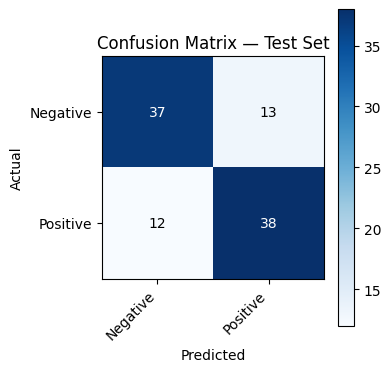

In [12]:
plot_confusion_matrix(
    model=model,
    loader=test_loader,
    num_classes=2,
    class_names=['Negative', 'Positive'],
    title='Confusion Matrix — Test Set',
)

---
## Scaling Up — 25 K Amazon Reviews

We now repeat the **exact same pipeline** on the larger `amazon_cells_labelled.txt` dataset (same tab-separated format, same binary labels).  The vectoriser and model are retrained **from scratch** on this corpus so the vocabulary properly reflects the larger training distribution.

### Load & Preprocess the Large Dataset

In [13]:
raw = pd.read_csv(
    '../data/amazon_cells_labelled_LARGE_25K.txt',
    delimiter='\t', header=None,
    names=['Sentence', 'Class'],
)
print(f'Loaded {len(raw)} reviews')
print(raw['Class'].value_counts().rename({0: 'Negative', 1: 'Positive'}))

data = preprocess_pandas(raw)
data.head()

Loaded 25000 reviews
Class
Positive    15116
Negative     9884
Name: count, dtype: int64


,Sentence,Class
0,ive read book much expectation boring book,0
1,love itvery touchits bad dvd description doesn...,1
2,creepiest book ive ever read creepy mysteryrom...,1
3,starts bit slow product placement jokes start ...,1
4,good book may print quality bad read zero star...,0


### Train / Validation / Test Split

In [14]:
sentences = data['Sentence'].values.astype('U')
labels    = data['Class'].values.astype('int32')

# Hold out 10 % as test set, then split remainder 90/10 → train/val
X_tv, X_test, y_tv, y_test = train_test_split(
    sentences, labels,
    test_size=0.10, random_state=SEED, stratify=labels,
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv,
    test_size=0.10, random_state=SEED, stratify=y_tv,
)

print(f'Train: {len(X_train):,}  |  Val: {len(X_val):,}  |  Test: {len(X_test):,}')

Train: 20,250  |  Val: 2,250  |  Test: 2,500


### TF-IDF Vectorisation

In [15]:
vectorizer = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),   # unigrams + bigrams: consider single words like "good" AND pairs like "not good"
    max_features=100_000, # cap vocabulary size
    max_df=0.5,           # drop words appearing in >50% of reviews
    use_idf=True,         # apply the IDF weighting
    norm='l2',            # normalize each row vector to unit length
)

vectorizer.fit(X_train)

X_train_t = torch.from_numpy(np.array(vectorizer.fit_transform(X_train).todense())).float()
X_val_t   = torch.from_numpy(np.array(vectorizer.transform(X_val).todense())).float()
X_test_t  = torch.from_numpy(np.array(vectorizer.transform(X_test).todense())).float()

y_train_t = torch.from_numpy(y_train).long()
y_val_t   = torch.from_numpy(y_val).long()
y_test_t  = torch.from_numpy(y_test).long()

INPUT_DIM = X_train_t.shape[1]
print(f'Vocabulary size (TF-IDF features): {INPUT_DIM}')

Vocabulary size (TF-IDF features): 100000


### DataLoaders

In [16]:
BATCH_SIZE = 256

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
)
val_loader = DataLoader(
    TensorDataset(X_val_t, y_val_t),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
)
test_loader = DataLoader(
    TensorDataset(X_test_t, y_test_t),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
)

### Model, Training & Evaluation

In [ ]:
HIDDEN_DIMS = [256, 64]
ACTIVATION = nn.ReLU
DROPOUT = 0.5
NUM_EPOCHS = 100
LEARNING_RATE = 1e-5
WEIGHT_DECAY = 1e-3

model = SentimentANN(
    input_dim=INPUT_DIM, 
    hidden_dims=HIDDEN_DIMS, 
    dropout=DROPOUT, 
    activation=ACTIVATION
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

wandb_kwargs = dict(
    entity="d7047e-group12",
    project="Lab1",
    name="TFIDF ANN 25K",
    tags=["Task 1.1", "TFIDF", "25K"],
    config={
        "dataset": "Amazon 25K",
        "optimizer": optimizer,
        "hidden_dims": HIDDEN_DIMS,
        "weight_decay": WEIGHT_DECAY,
        "lr": LEARNING_RATE,
        "epochs": NUM_EPOCHS,
        "batch_size": BATCH_SIZE,
    },
)

history = fit(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=NUM_EPOCHS,
    wandb_kwargs=wandb_kwargs,
    log=LOG_WANDB,
)

Epoch   1/100 | train loss 0.7266, train acc 52.91% | val loss 0.6637, val acc 69.47%
Epoch   2/100 | train loss 0.6343, train acc 63.88% | val loss 0.5671, val acc 77.07%
Epoch   3/100 | train loss 0.5557, train acc 72.40% | val loss 0.5248, val acc 80.80%
Epoch   4/100 | train loss 0.4890, train acc 79.29% | val loss 0.4880, val acc 83.24%


### Test-Set Evaluation & Confusion Matrix

In [ ]:
evaluate(model, test_loader, criterion, label='ANN TF-IDF — 25K Samples')

In [ ]:
plot_confusion_matrix(
    model=model,
    loader=test_loader,
    num_classes=2,
    class_names=['Negative', 'Positive'],
    title='Confusion Matrix — Large Dataset Test Set',
)